In [9]:
import pandas as pd
import scipy
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random

In [10]:
mat_data = scipy.io.loadmat('../Data/Xtrain.mat')


In [11]:
print(mat_data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


In [12]:
X = mat_data['Xtrain']
print(f"Feature shape: {X.shape}")

Feature shape: (1000, 1)


In [13]:
raw_data = X.astype(np.float32).flatten()

In [14]:
def create_data(data, window):
    rows = [data[i : i + window] for i in range(len(data) - window + 1)]
    columns = [f"x{i}" for i in range(window - 1)] + ["y"]

    return pd.DataFrame(rows, columns=columns)

In [ ]:

split_idx = int(len(raw_data) * 0.8)
train_raw = np.array(raw_data[:split_idx]).reshape(-1, 1)
test_raw = np.array(raw_data[split_idx:]).reshape(-1, 1)

# 2. Fit the scaler ONLY on training data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw).flatten()

test_scaled = scaler.transform(test_raw).flatten()

In [16]:
class LaserDataset(Dataset):
    def __init__(self, df):
        # Separate features (X) and target (y)
        self.X = torch.tensor(df.drop('y', axis=1).values, dtype=torch.float32)
        self.y = torch.tensor(df['y'].values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [17]:
class LaserPredictor(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super(LaserPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 64 outputs
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 32 outputs
            
            nn.Linear(32, 1) # Never put dropout on the final output layer
        )

    def forward(self, x):
        return self.network(x)

In [18]:
def recursive_data_generation(x, model, k, num_samples) -> np.ndarray:
    """
    x: window
    model: model
    k: window size
    num_samples: number of predictions
    """
    # Evaluation Mode
    model.eval()

    # Initialize predicted samples array
    predicted_samples = np.zeros(num_samples, dtype=np.float32)

    # Make sure x is torch.tensor and not np.ndarray

    x = torch.tensor(x, dtype=torch.float32)

    # Make sure len(x) == k
    if len(x) > k:
        x = x[-k:].clone()
    elif len(x) < k:
        print(f"Window size of x must be at least {k} samples long")
        return np.empty((0, num_samples), dtype=np.float32)


    with torch.no_grad():
        for i in range(num_samples):
            # Predict next sample
            y = model(x)
            # Concatenate last-k window
            x = torch.cat([x[1:], y])
            # Add to prediction samples array
            predicted_samples[i] = y.item()

    return predicted_samples

In [19]:
# Configuration
window_sizes = [i for i in range(3, 10)] # Started at 2 because window < 2 has no features
shuffle_options = [True, False]
# seeds = [42, 123, 999, 7, 2024, 222, 153, 23, 1111, 1263] # 10 different seeds
seeds = [random.randint(0, 2000) for _ in range(10)]
print(seeds)
epochs = 100 # Reduced slightly for the search; you can set back to 100
results = []

def set_seed(seed):
    """Utility to ensure reproducibility for each trial"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
shuffle_flag = True
for w in window_sizes:
        
        # Store val losses for the 5 seeds to average them later
        seed_val_losses = []
        seed_train_losses = []
        
        for seed in seeds:
            set_seed(seed) # Reset math state for this specific trial
            # print(f"seed value: {seed}")
            
            # 1. Re-generate data
            df_train = create_data(train_scaled, window=w)
            df_test = create_data(test_scaled, window=w)
            
            train_loader = DataLoader(LaserDataset(df_train), batch_size=32, shuffle=shuffle_flag)
            test_loader = DataLoader(LaserDataset(df_test), batch_size=32, shuffle=False)
            
            # 2. Initialize Model
            model = LaserPredictor(input_size=w - 1)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
            criterion = torch.nn.MSELoss()
            
            # 3. Training Loop
            for epoch in range(epochs):
                model.train()
                total_train_loss = 0
                for batch_X, batch_y in train_loader:
                    optimizer.zero_grad()
                    loss = criterion(model(batch_X), batch_y)
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.item()
                
                # We calculate validation at the END of the training for this seed
                if epoch == epochs - 1:
                    window = list(train_scaled[-(w-1):])
                    preds = recursive_data_generation(x=window,model=model,k=w-1,num_samples=len(test_scaled))
                    recursive_val_mse = mean_squared_error(test_scaled, preds)
                    
                    seed_val_losses.append(recursive_val_mse)
                    seed_train_losses.append(total_train_loss / len(train_loader))

        # 4. Calculate averages across the 5 seeds
        avg_val_loss = np.mean(seed_val_losses)
        avg_train_loss = np.mean(seed_train_losses)
        std_val_loss = np.std(seed_val_losses) # Also useful to see how "stable" the window is

        results.append({
            'window_size': w,
            'shuffled': shuffle_flag,
            'avg_train_loss': avg_train_loss,
            'avg_val_loss': avg_val_loss,
            'val_std_dev': std_val_loss
        })

# 5. Final Results
results_df = pd.DataFrame(results)
print(f"\nFinal Experiment Results (Averaged over {len(seeds)} seeds):")
print(results_df.sort_values('avg_val_loss').head(10)) # Show top 10 configurations

[854, 1566, 189, 263, 1522, 686, 224, 1252, 1325, 1830]

Final Experiment Results (Averaged over 10 seeds):
   window_size  shuffled  avg_train_loss  avg_val_loss  val_std_dev
6            9      True        0.001884      0.028720     0.008912
4            7      True        0.002241      0.029767     0.005806
2            5      True        0.002548      0.029975     0.003464
1            4      True        0.002715      0.030621     0.007227
3            6      True        0.002381      0.032785     0.002497
5            8      True        0.002331      0.036032     0.014113
0            3      True        0.002632      0.039636     0.013812


In [20]:
results_df.sort_values('avg_val_loss')

,window_size,shuffled,avg_train_loss,avg_val_loss,val_std_dev
6,9,True,0.001884,0.028720,0.008912
4,7,True,0.002241,0.029767,0.005806
2,5,True,0.002548,0.029975,0.003464
1,4,True,0.002715,0.030621,0.007227
3,6,True,0.002381,0.032785,0.002497
5,8,True,0.002331,0.036032,0.014113
0,3,True,0.002632,0.039636,0.013812


In [66]:
BEST_WINDOW = results_df.sort_values('avg_val_loss').head(1)["window_size"].values[0]
# BEST_WINDOW = int(BEST_WINDOW.mean())
BEST_WINDOW = 30

In [67]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0, path='best_checkpoint.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [68]:
def init_weights_kaiming(m):
    if isinstance(m, nn.Linear):
        # Good for ReLU: variance is 2/n
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [93]:
import copy

# 1. Final Configuration
# BEST_WINDOW = 15 # Ensure this matches your findings
SHUFFLE_TRAIN = True
EPOCHS = 500 
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
PATIENCE = 100 

seeds = [random.randint(0, 2000) for _ in range(10)]
trained_models = [] # This will store your 10 best models

# 2. Data Preparation (Fixed for all seeds)
df_train = create_data(train_scaled, window=BEST_WINDOW)
# df_test = create_data(test_scaled, window=BEST_WINDOW)
train_loader = DataLoader(LaserDataset(df_train), batch_size=64, shuffle=SHUFFLE_TRAIN)
# test_loader = DataLoader(LaserDataset(df_test), batch_size=64, shuffle=False)

# 3. Outer Loop: Iterate through each seed
for i, seed in enumerate(seeds):
    print(f"\n=== Training Model {i+1}/10 | Seed: {seed} ===")
    set_seed(seed) # Ensure reproducibility for this specific run
    
    # Initialize Model, Optimizer, and Early Stopper
    model = LaserPredictor(input_size=BEST_WINDOW - 1)
    # model.apply(init_weights_kaiming) # Apply the Kaiming initialization
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = torch.nn.MSELoss()
    
    # Unique path for each seed's best checkpoint
    checkpoint_path = f'model{i}.pth'
    early_stopper = EarlyStopping(patience=PATIENCE, path=checkpoint_path)

    # 4. Training Loop
    for epoch in range(EPOCHS):
        # --- TRAINING PHASE ---
        model.train()
        total_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        
        # --- RECURSIVE VALIDATION PHASE ---
        window = list(train_scaled[-(BEST_WINDOW-1):])
        # print(f"window: {window}")
        preds = recursive_data_generation(x=window,model=model,k=BEST_WINDOW-1,num_samples=len(test_scaled))
        recursive_val_mse = mean_squared_error(test_scaled, preds)
        
                
        avg_train = total_train_loss / len(train_loader)
        
        # Check early stopping against the recursive performance
        early_stopper(recursive_val_mse, model)
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train:.6f} | Rec-Val MSE: {recursive_val_mse:.6f}")

        if early_stopper.early_stop:
            print(f"Early stopping at epoch {epoch+1}. Best Rec-Val MSE: {early_stopper.best_loss:.6f}")
            break

    # 5. Load best weights and store the model
    model.load_state_dict(torch.load(checkpoint_path))
    trained_models.append(copy.deepcopy(model)) # Store the best version of this model
    print(f"Model {i+1} saved to list.")

print("\nAll 10 models have been trained and stored in 'trained_models'.")
joblib.dump(scaler, 'laser_scaler_ensemble.pkl')


=== Training Model 1/10 | Seed: 1123 ===
Epoch [50/500] | Train Loss: 0.004680 | Rec-Val MSE: 0.095342
Epoch [100/500] | Train Loss: 0.002572 | Rec-Val MSE: 0.025120
Epoch [150/500] | Train Loss: 0.002406 | Rec-Val MSE: 0.024019
Epoch [200/500] | Train Loss: 0.002027 | Rec-Val MSE: 0.025330
Early stopping at epoch 210. Best Rec-Val MSE: 0.003108
Model 1 saved to list.

=== Training Model 2/10 | Seed: 686 ===
Epoch [50/500] | Train Loss: 0.003956 | Rec-Val MSE: 0.032425
Epoch [100/500] | Train Loss: 0.001783 | Rec-Val MSE: 0.044591
Early stopping at epoch 133. Best Rec-Val MSE: 0.006129
Model 2 saved to list.

=== Training Model 3/10 | Seed: 1537 ===
Epoch [50/500] | Train Loss: 0.004347 | Rec-Val MSE: 0.089725
Epoch [100/500] | Train Loss: 0.002431 | Rec-Val MSE: 0.018662
Epoch [150/500] | Train Loss: 0.002410 | Rec-Val MSE: 0.008217
Early stopping at epoch 194. Best Rec-Val MSE: 0.002514
Model 3 saved to list.

=== Training Model 4/10 | Seed: 269 ===
Epoch [50/500] | Train Loss: 0.00

['laser_scaler_ensemble.pkl']

In [94]:
# class LaserPredictor(nn.Module):
#     def __init__(self, input_size, dropout_rate=0.2):
#         super(LaserPredictor, self).__init__()
#         self.network = nn.Sequential(
#             nn.Linear(input_size, 64),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 64 outputs
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 32 outputs
#             nn.Linear(32, 1) # Never put dropout on the final output layer
#         )

#     def forward(self, x):
#         return self.network(x)

# def init_weights_kaiming(m):
#     if isinstance(m, nn.Linear):
#         # Good for ReLU: variance is 2/n
#         nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
#         if m.bias is not None:
#             nn.init.constant_(m.bias, 0)
            
# # 2. Initialize and Load
# # Use the same BEST_WINDOW (15) from your training
# model = LaserPredictor(input_size=BEST_WINDOW -1) 
# model.load_state_dict(torch.load('laser_predictor_feedforward.pth'))
# # model.eval()  # CRITICAL: Sets the model to inference mode

# # 3. Load the Scaler
# scaler = joblib.load('laser_scaler_feedforward.pkl')

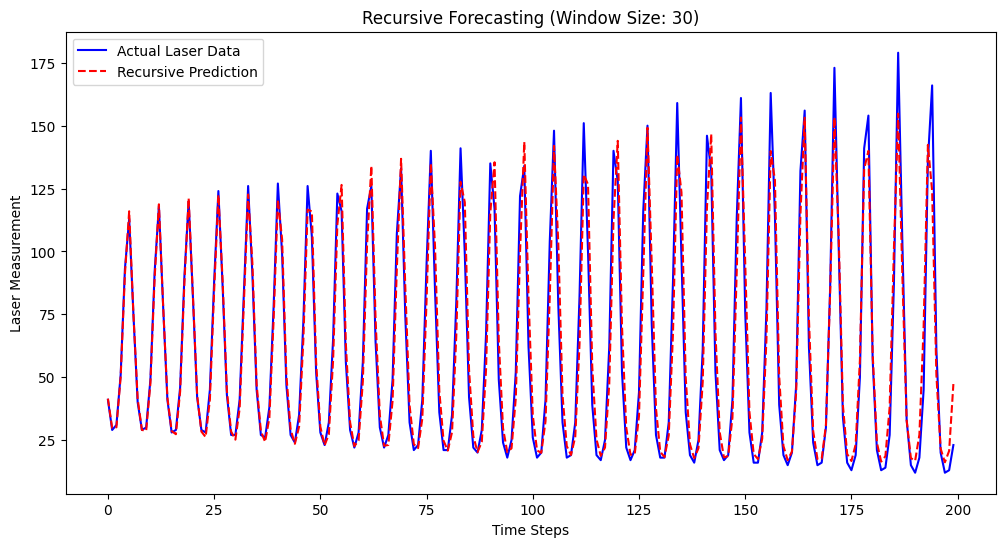

In [95]:
# Assuming window size is 15, so input_size is 14
k_minus_1 = BEST_WINDOW - 1

# 1. Take the last points from the SCALED training data
current_window = list(train_scaled[-k_minus_1:])

# 2. Collect predictions from every model in the ensemble
all_model_runs = []

for i, model in enumerate(trained_models):
    model.eval() # Ensure model is in inference mode
    # Generate recursive predictions for this specific model
    preds = recursive_data_generation(
        x=current_window, 
        model=model, 
        k=k_minus_1, 
        num_samples=len(test_scaled)
    )
    all_model_runs.append(preds)

# 3. Calculate the average across all models (Ensemble Averaging)
# all_model_runs is a list of arrays; np.mean(..., axis=0) averages them point-by-point
avg_predictions = np.mean(all_model_runs, axis=0).reshape(-1, 1)

# 4. Inverse transform and save
final_forecast = scaler.inverse_transform(avg_predictions)
scipy.io.savemat('predictions/predictions.mat', {'pred_var': final_forecast})
actual_test_values = scaler.inverse_transform(test_scaled.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(actual_test_values, label='Actual Laser Data', color='blue')
plt.plot(final_forecast, label='Recursive Prediction', color='red', linestyle='--')
plt.title(f"Recursive Forecasting (Window Size: {k_minus_1+1})")
plt.xlabel("Time Steps")
plt.ylabel("Laser Measurement")
plt.legend()
plt.show()

In [96]:
mae = mean_absolute_error(actual_test_values, final_forecast)
mse = mean_squared_error(actual_test_values, final_forecast)
rmse = np.sqrt(mse) # Root Mean Squared Error is also very helpful

print(f"--- Recursive Forecast Metrics (Original Units) ---")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

--- Recursive Forecast Metrics (Original Units) ---
MAE : 7.6872
MSE : 115.6905
RMSE: 10.7560


In [85]:
for p,r in zip(final_forecast, actual_test_values):
    print(f"prediction: {p}, truth: {r}, difference: {abs(p - r)}")

prediction: [39.483253], truth: [41.], difference: [1.5167465]
prediction: [28.354858], truth: [29.], difference: [0.6451416]
prediction: [29.246834], truth: [31.], difference: [1.7531662]
prediction: [46.990192], truth: [51.], difference: [4.0098076]
prediction: [88.85602], truth: [93.], difference: [4.143982]
prediction: [113.81844], truth: [113.], difference: [0.8184433]
prediction: [75.834946], truth: [75.], difference: [0.8349457]
prediction: [40.165897], truth: [40.], difference: [0.16589737]
prediction: [28.01014], truth: [29.], difference: [0.98986053]
prediction: [28.18868], truth: [30.], difference: [1.8113194]
prediction: [43.825043], truth: [49.], difference: [5.1749573]
prediction: [84.8757], truth: [92.], difference: [7.124298]
prediction: [115.372055], truth: [118.], difference: [2.627945]
prediction: [79.946205], truth: [78.], difference: [1.9462051]
prediction: [41.794613], truth: [41.], difference: [0.7946129]
prediction: [27.917105], truth: [28.], difference: [0.0828